# Part B – Sarvein: Supervised Text Classification (SVM Model)

**Dataset:** IMDB Dataset of 50K Movie Reviews  
**Task:** Binary Sentiment Classification — `positive` vs `negative`  
**Model:** Support Vector Machine (SVM) with TF-IDF features


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Download required NLTK data
nltk.download('stopwords', quiet=True)



True

In [ ]:
# ── Load Dataset ──────────────────────────────────────────────────────────────

df = pd.read_csv('IMDB Dataset.csv')

# Encode label: positive = 1, negative = 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Dataset shape  : {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
df.head(3)


Dataset shape  : (49582, 3)

Class distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [ ]:
# ── Text Preprocessing ────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Lowercase and tokenise
    tokens = text.lower().split()
    # 4 & 5. Remove stop words and stem
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)


df['clean_review'] = df['review'].apply(clean_text)
print(f"Done. Sample cleaned review:\n\n{df['clean_review'].iloc[0][:300]}")


Done. Sample cleaned review:

one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli e


In [6]:
# ── Train/Test Split & TF-IDF Vectorisation ───────────────────────────────────
X = df['clean_review']
y = df['label']

# 80/20 stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: convert text to numerical feature matrix
# max_features=40000 adjusted for cleaned dataset size
# ngram_range=(1,2) includes unigrams and bigrams
tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit on training data only
X_test_tfidf  = tfidf.transform(X_test)         # transform test data

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"TF-IDF features  : {X_train_tfidf.shape[1]}")

Training samples : 39665
Test samples     : 9917
TF-IDF features  : 40000


In [7]:
# ── Build & Train SVM Model ───────────────────────────────────────────────────

svm_model = LinearSVC(C=1.0, max_iter=1000, random_state=42)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully.")


SVM model trained successfully.


In [8]:
# ── Model Evaluation ─────────────────────────────────────────────────────────
y_pred = svm_model.predict(X_test_tfidf)

# Compute evaluation metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 45)
print("         SVM MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


         SVM MODEL EVALUATION RESULTS
  Accuracy  : 0.9002  (90.02%)
  Precision : 0.8977
  Recall    : 0.9042
  F1-Score  : 0.9009

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      4940
    Positive       0.90      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



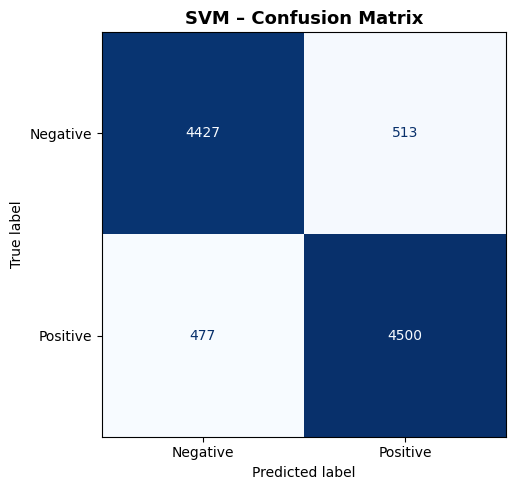

In [9]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM – Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



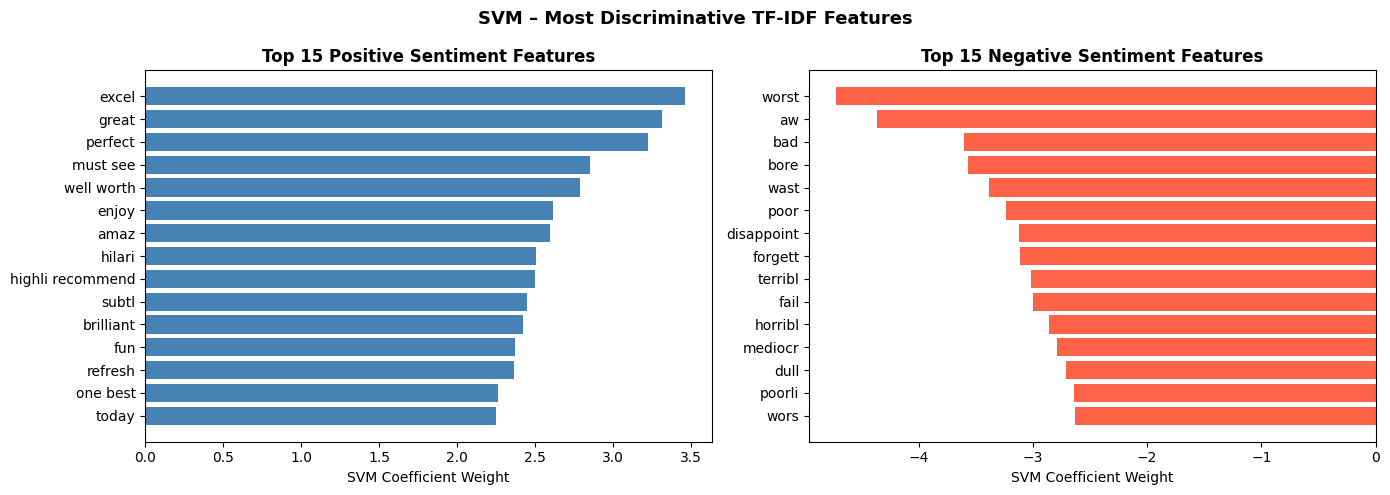

In [10]:
# ── Top Discriminative Features ───────────────────────────────────────────────
# Positive weights: associated with positive sentiment
# Negative weights: associated with negative sentiment

feature_names = tfidf.get_feature_names_out()
coef = svm_model.coef_[0]

top_n = 15
top_pos_idx = coef.argsort()[-top_n:][::-1]   # highest weights
top_neg_idx = coef.argsort()[:top_n]           # lowest (most negative) weights

top_pos_words   = [feature_names[i] for i in top_pos_idx]
top_pos_weights = [coef[i] for i in top_pos_idx]
top_neg_words   = [feature_names[i] for i in top_neg_idx]
top_neg_weights = [coef[i] for i in top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos_words[::-1], top_pos_weights[::-1], color='steelblue')
axes[0].set_title('Top 15 Positive Sentiment Features', fontweight='bold')
axes[0].set_xlabel('SVM Coefficient Weight')

axes[1].barh(top_neg_words[::-1], top_neg_weights[::-1], color='tomato')
axes[1].set_title('Top 15 Negative Sentiment Features', fontweight='bold')
axes[1].set_xlabel('SVM Coefficient Weight')

plt.suptitle('SVM – Most Discriminative TF-IDF Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



---
# Part B – Q3: Hyperparameter Tuning (SVM)

GridSearchCV is used to systematically search over a defined parameter grid.  
5-fold cross-validation is applied on the training set for each combination.


In [11]:
# ── GridSearchCV ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {
    'C'        : [0.01, 0.1, 1.0, 10.0],
    'loss'     : ['hinge', 'squared_hinge'],
    'max_iter' : [500, 1000]
}

# Initialise the base estimator
svm_base = LinearSVC(random_state=42)

# GridSearchCV with 5-fold cross-validation, scoring on F1 (macro)
# n_jobs=-1 uses all available CPU cores
grid_search = GridSearchCV(
    estimator  = svm_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1
)

print("Running GridSearchCV over the following grid:")
print(param_grid)

grid_search.fit(X_train_tfidf, y_train)

print("\nGridSearchCV complete.")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")


Running GridSearchCV over the following grid:
{'C': [0.01, 0.1, 1.0, 10.0], 'loss': ['hinge', 'squared_hinge'], 'max_iter': [500, 1000]}
Fitting 5 folds for each of 16 candidates, totalling 80 fits

GridSearchCV complete.
Best Parameters : {'C': 1.0, 'loss': 'hinge', 'max_iter': 500}
Best CV F1 Score: 0.8999


In [12]:
# ── Evaluate Best Tuned SVM on Test Set ───────────────────────────────────────
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_tfidf)

acc_t   = accuracy_score(y_test, y_pred_tuned)
prec_t  = precision_score(y_test, y_pred_tuned)
rec_t   = recall_score(y_test, y_pred_tuned)
f1_t    = f1_score(y_test, y_pred_tuned)

print("=" * 50)
print("     TUNED SVM MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc_t:.4f}  ({acc_t*100:.2f}%)")
print(f"  Precision : {prec_t:.4f}")
print(f"  Recall    : {rec_t:.4f}")
print(f"  F1-Score  : {f1_t:.4f}")
print("=" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Positive']))


     TUNED SVM MODEL EVALUATION RESULTS
  Accuracy  : 0.9017  (90.17%)
  Precision : 0.8950
  Recall    : 0.9110
  F1-Score  : 0.9029

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



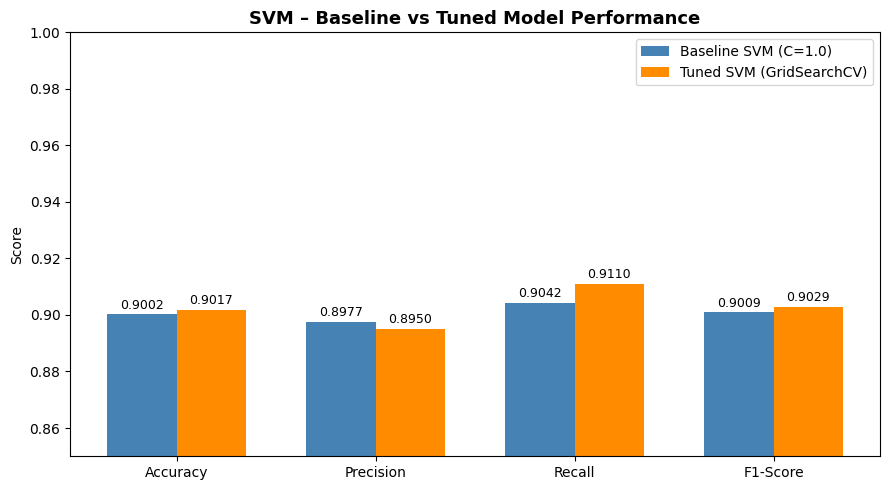

In [13]:
# ── Before vs After Tuning Comparison ────────────────────────────────────────
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [acc,   precision, recall, f1]
tuned_vals    = [acc_t, prec_t,    rec_t,  f1_t]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline SVM (C=1.0)',  color='steelblue')
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned SVM (GridSearchCV)', color='darkorange')

ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('SVM – Baseline vs Tuned Model Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Annotate bars with exact values
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

